In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [4]:
iris = datasets.load_iris()

# Take only 2 features
X = iris.data[:, :2]

# Take target
y = iris.target

# Keep only 2 classes (0 and 1)
X = X[y != 2]
y = y[y != 2]

In [6]:
class Perceptron:

    def __init__(self):
        self.lr = 0.1
        self.epochs = 1000
        self.w = None
        self.b = 0

    def step(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            for i in range(len(X)):
                linear = np.dot(X[i], self.w) + self.b
                y_pred = self.step(linear)

                update = self.lr * (y[i] - y_pred)

                self.w += update * X[i]
                self.b += update

    def predict(self, X):
        result = []
        for x in X:
            linear = np.dot(x, self.w) + self.b
            result.append(self.step(linear))
        return np.array(result)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Perceptron()
model.fit(X_train, y_train)

In [8]:
pred = model.predict(X_test)

accuracy = np.mean(pred == y_test)
print("Accuracy:", accuracy * 100)

Accuracy: 95.0


In [9]:
def plot(X, y, model):

    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)

    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.title("Decision Boundary")

    plt.show()

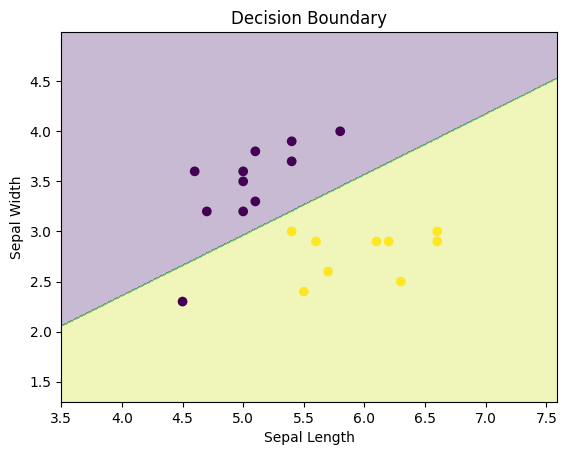

In [10]:
plot(X_test, y_test, model)